## Equations

The system can be described as follows:

$$
\frac{\partial\xi}{\partial t}+\frac{\partial\psi}{\partial x}\frac{\partial\xi}{\partial y}-\frac{\partial\psi}{\partial y}\frac{\partial\xi}{\partial x}=0
$$

$$
\nabla^2\psi=\xi
$$

where $\psi$ is the streamfunction and $\xi$ is the vorticity. The velocity components are given by $u=-\partial\psi/\partial y$ and $v=\partial\psi/\partial x$.

Here, the system will be bounded within $0\leq x\leq 10$ and $0\leq y\leq 10$. The boundary condition is simply assumed as $\psi_{boundary}=0$ and $\xi_{boundary}=0$.

The two vortices are initially located at $(x_0, y_0)=(4,6)$ and $(x_1,y_1)=(6,6)$, with the vorticity field due to each vortex given by

$$
\xi_0(x,y)=\exp \left[ -6\left((x-4)^2+(y-6)^2\right) \right]
$$
$$
\xi_1(x,y)=-\exp \left[ -6\left((x-6)^2+(y-6)^2\right) \right]
$$

## Computational Methods

Setup a $101\times 101$ grid. Compute the inital vorticity field $\xi_{ij}^0$ from the given initial conditions. Solve the Poisson equation $\nabla^2\psi=\xi$ for the initial streamfunction field $\psi_{ij}^0$ with the given boundary conditions. Determine a proper $\alpha$ value from the initial velocity.

Then, integrate the vorticity equation with a forward timestep for $\xi_{ij}^1$, evaluate the Jacobian term and solve the Poisson equation for $\psi_{ij}^1$.

For subsequent timesteps, compute by the leapfrog scheme.

In [165]:
import numpy as np

# Set up initial conditions and boundary conditions
Lx, Ly = 10.0, 10.0
Nx, Ny = 101, 101
dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)
D = dx

x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y, indexing='ij')

x0, y0 = 4.0, 6.0
x1, y1 = 6.0, 6.0
xi_0 = -np.exp(-6 * ((X-x0)**2 + (Y-y0)**2))
xi_1 = np.exp(-6 * ((X-x1)**2 + (Y-y1)**2))
vor = xi_0 + xi_1
vor[0, :] = 0
vor[-1, :] = 0
vor[:, 0] = 0
vor[:, -1] = 0

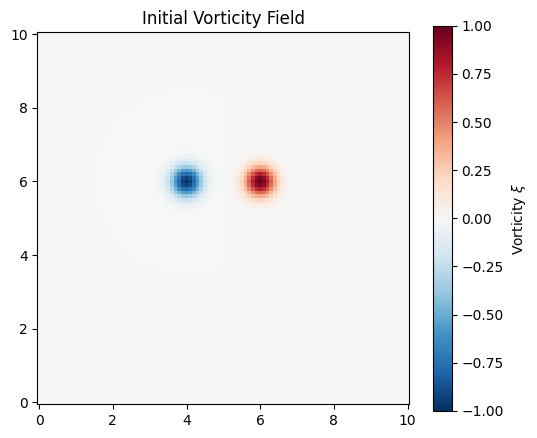

In [166]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 5))
plt.pcolormesh(X, Y, vor, cmap='RdBu_r', shading='auto')
plt.colorbar(label='Vorticity $\\xi$')
plt.title('Initial Vorticity Field')
plt.gca().set_aspect('equal')
plt.show()

To solve the Poisson equation, since $\psi_{0,q}=\psi_{10,q}=\psi_{p,0}=\psi_{p,10}=0$, which is Dirichlet boundary condition, therefore, the eigen functions are sine functions. This is the Discrete Sine Transform (DST).

$$
\psi_{p,q}=\sum_{i,j} C_{i,j} \sin{\left(\frac{i\pi p}{M+1} \right) \sin{\left(\frac{j\pi q}{N+1}\right)}}
$$

Put the sine expansion into the discretized Poisson function, we get the eigenvalues:

$$
\lambda_{i,j}=2\left( \cos{\left(\frac{i\pi}{M+1}\right)} + \cos{\left(\frac{j\pi}{N+1}\right)}-2 \right)
$$

Therefore, $\lambda_{i,j}\cdot \hat\psi_{i,j}=D^2\cdot \hat\xi_{i,j}$.

In [167]:
# PoiSin
# Calculate coefficients D^2/lambda for every (i, j)
def PoiSin(ML, NL, D):
    M = ML - 2
    N = NL - 2
    i = np.arange(1, M + 1)
    j = np.arange(1, N + 1)
    I, J = np.meshgrid(i, j, indexing='ij')
    PoiSinCoe = (D * D / 2) / (np.cos(I * np.pi / (M + 1)) + np.cos(J * np.pi / (N + 1)) - 2)
    return PoiSinCoe

In [168]:
# Poisson
# Solve the Poisson equation by sine-transform
from scipy.fft import dst, idst
def Poisson(ML, NL, PoiSinCoe, vor):
    st = np.zeros((ML, NL))
    vot = vor[1:-1, 1:-1]

    # 2D Sine-transform (DST)
    vordst = dst(vot, type=1, axis=0, norm='ortho')
    vordst = dst(vordst, type=1, axis=1, norm='ortho')

    phidst = vordst * PoiSinCoe

    # Reverse Transform (2D IDST)
    phidst = idst(phidst, type=1, axis=1, norm='ortho')
    phidst = idst(phidst, type=1, axis=0, norm='ortho')
    st[1:-1, 1:-1] = phidst
    return st

Then, solve the Poisson equation for $\psi_{ij}^0$.

In [169]:
poi_sin_coe = PoiSin(Nx, Ny, D)
psi_0 = Poisson(Nx, Ny, poi_sin_coe, vor)

In [170]:
# Calculate for the velocity
u = np.zeros((Nx, Ny))
v = np.zeros((Nx, Ny))
u[1:-1, 1:-1] = -(psi_0[1:-1, 2:] - psi_0[1:-1, :-2]) / (2 * dx)
v[1:-1, 1:-1] = (psi_0[2:, 1:-1] - psi_0[:-2, 1:-1]) / (2 * dy)

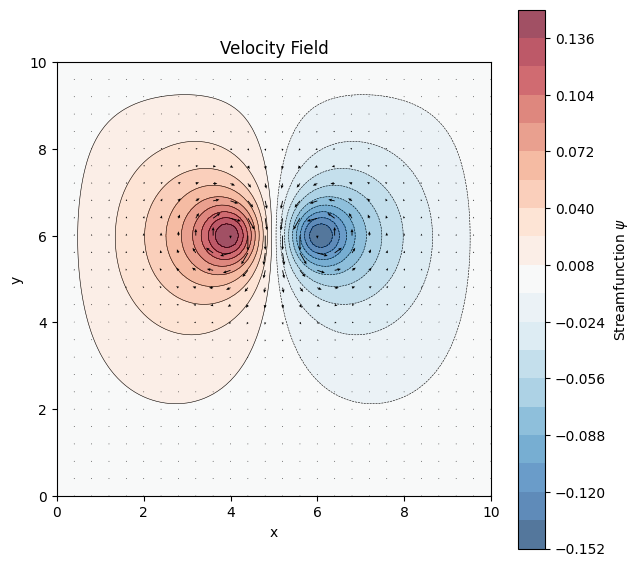

In [171]:
plt.figure(figsize=(7, 7))

levels = np.linspace(np.min(psi_0), np.max(psi_0), 20)
plt.contour(X, Y, psi_0, levels=levels, colors='k', linewidths=0.4)
plt.contourf(X, Y, psi_0, levels=levels, cmap='RdBu_r', alpha=0.7)
plt.colorbar(label='Streamfunction $\\psi$')

step = 4
plt.quiver(X[::step, ::step], Y[::step, ::step], 
           u[::step, ::step], v[::step, ::step], 
           color='black', scale=5, width=0.002, headlength=4, headwidth=3.5, headaxislength=3.5)

plt.title('Velocity Field')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0, Lx)
plt.ylim(0, Ly)
plt.gca().set_aspect('equal')
plt.show()

In [172]:
# Calculate a proper alpha value for leapfrog scheme.
v_mag = np.sqrt(u**2 + v**2)
v_max = np.max(v_mag)
print(f"|v_max| = {v_max:.4f}")
alpha=0.25
dt = alpha * D / v_max
print(f'Calculated dt = {dt:.6f}')

|v_max| = 0.1787
Calculated dt = 0.139913


In [173]:
# ArakawaJ: Compute the Arakawa Jacobian
def ArakawaJ(A, B, D):
    # J(A,B)=(dA/dx)(dB/dy)-(dA/dy)(dB/dx)
    ML, NL = A.shape
    JAB = np.zeros((ML, NL))
    dd12 = 1 / (12.0 * D * D)

    A_r = A[2:, 1:-1];   B_r = B[2:, 1:-1]
    A_l = A[:-2, 1:-1];  B_l = B[:-2, 1:-1]
    A_t = A[1:-1, 2:];   B_t = B[1:-1, 2:]
    A_d = A[1:-1, :-2];  B_d = B[1:-1, :-2]

    A_tr = A[2:, 2:];    B_tr = B[2:, 2:]
    A_tl = A[:-2, 2:];   B_tl = B[:-2, 2:]
    A_dr = A[2:, :-2];   B_dr = B[2:, :-2]
    A_dl = A[:-2, :-2];  B_dl = B[:-2, :-2]

    PJ =  A_r  * (B_t - B_d + B_tr - B_dr)
    PJ += A_tr * (B_t - B_r)
    PJ += A_t  * (B_l - B_r + B_tl - B_tr)
    PJ += A_tl * (B_l - B_t)
    PJ += A_l  * (B_d - B_t + B_dl - B_tl)
    PJ += A_dl * (B_d - B_l)
    PJ += A_d  * (B_r - B_l + B_dr - B_dl)
    PJ += A_dr * (B_r - B_d)
    JAB[1:-1, 1:-1] = PJ * dd12
    return JAB

Do a forward timestep to start the simulation.

$$
\xi^1 = \xi^0 - \Delta t\cdot J(\psi^0, \xi^0)
$$

In [174]:
# Forward timestep for t=dt
J_0 = ArakawaJ(psi_0, vor, D)
vor_1 = vor - dt * J_0
vor_1[0, :] = 0
vor_1[10, :] = 0
vor_1[:, 0] = 0
vor_1[:, 10] = 0
psi_1 = Poisson(Nx, Ny, poi_sin_coe, vor_1)

Now, run the Leapfrog Scheme for the simuation.

$$
\xi^{n+1}=\xi^{n-1} - 2\Delta t\cdot J(\psi^n,\xi^n)
$$

In [175]:
def plot_vel_field(ax, psi, title):
    u = np.zeros((Nx, Ny))
    v = np.zeros((Nx, Ny))
    u[1:-1, 1:-1] = -(psi[1:-1, 2:] - psi[1:-1, :-2]) / (2 * dy)
    v[1:-1, 1:-1] = (psi[2:, 1:-1] - psi[:-2, 1:-1]) / (2 * dx)

    cf = ax.contourf(X, Y, psi, levels=levels, cmap='RdBu_r', alpha=0.7, extend='both')
    ax.contour(X, Y, psi, levels=levels, colors='k', linewidths=0.4)

    ax.quiver(X[::step_q, ::step_q], Y[::step_q, ::step_q], 
               u[::step_q, ::step_q], v[::step_q, ::step_q], 
               color='black', scale=5, width=0.002, 
               headlength=4, headwidth=3.5, headaxislength=3.5)
              
    ax.set_title(title)
    ax.set_xlim(0, Lx)
    ax.set_ylim(0, Ly)
    ax.set_aspect('equal')

    return cf

[1, 477, 954, 1430, 1907, 2383, 2859, 3336, 3812, 4288, 4765, 5241, 5718, 6194, 6670, 7147]


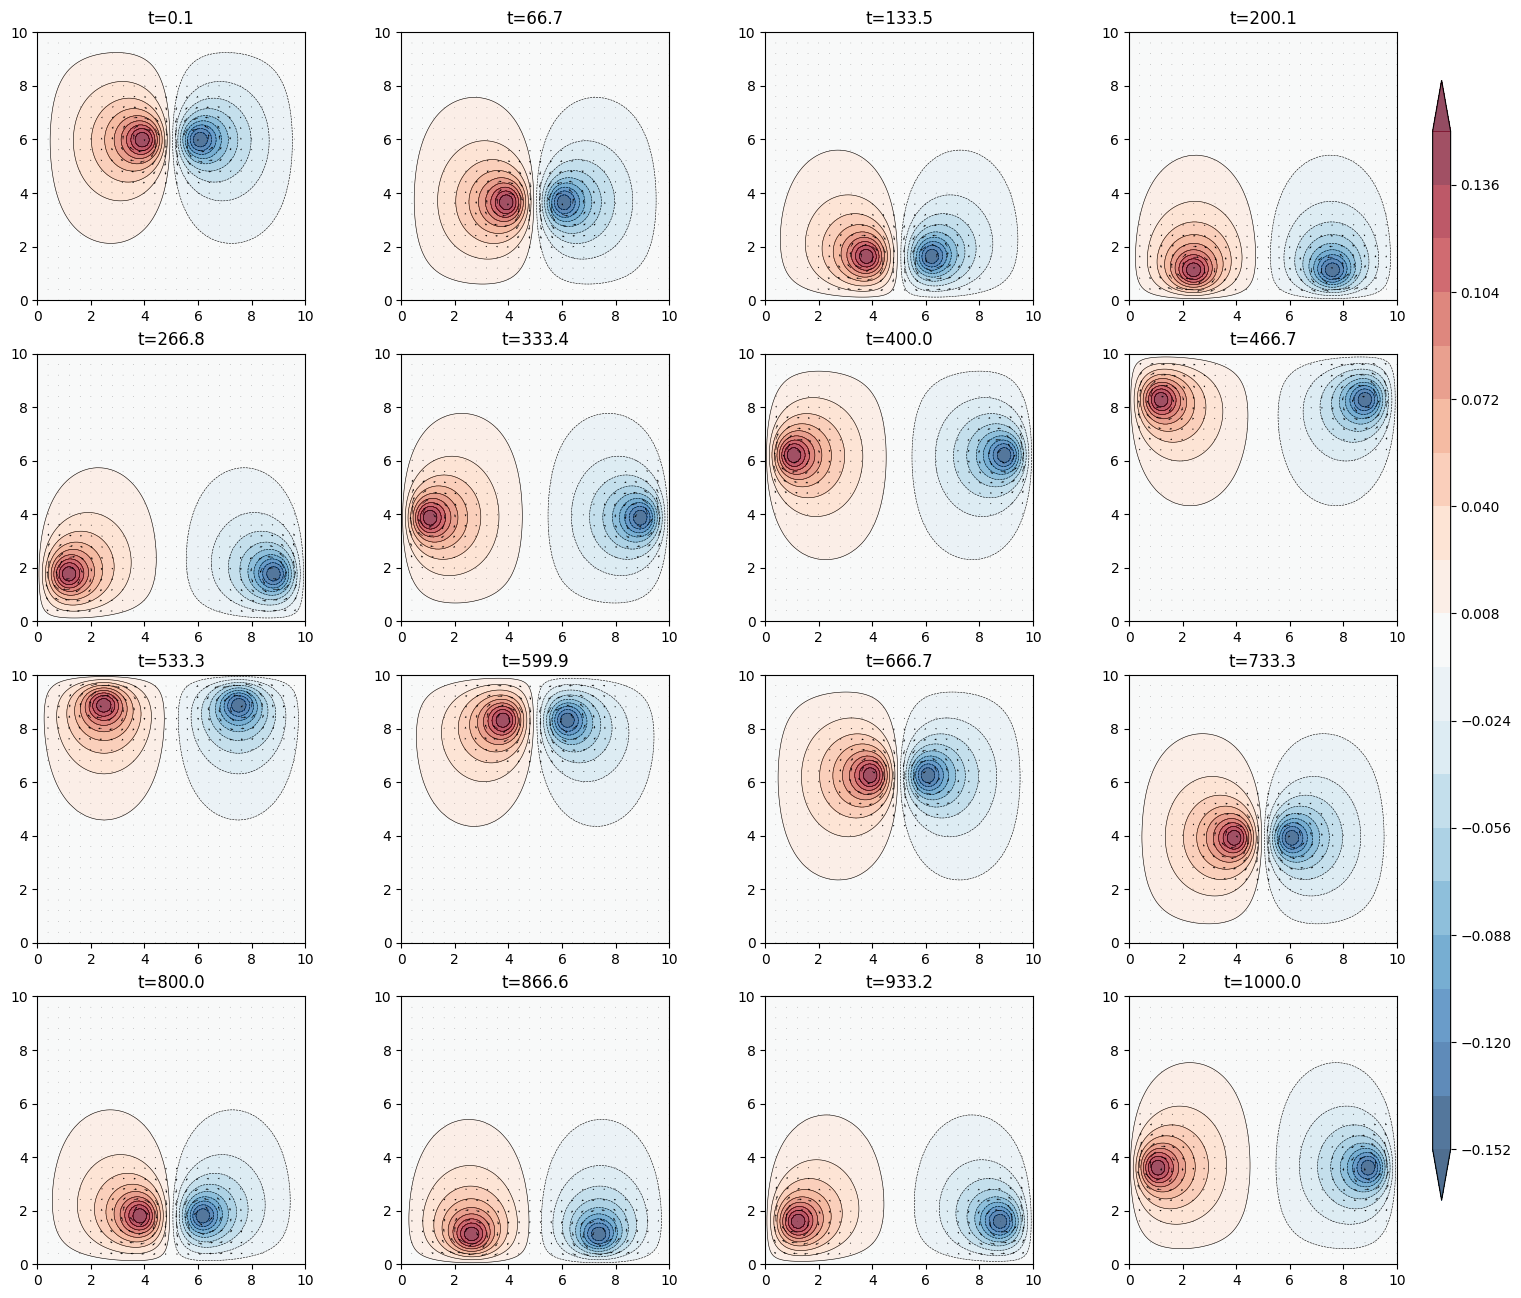

In [176]:
T_total = 1000.0
num_steps = int(T_total / dt)

vor_old = vor.copy()
vor_curr = vor_1.copy()
psi_curr = psi_1.copy()

tar_times = np.linspace(0.2, T_total, 16)
tar_steps = [int(t / dt) for t in tar_times]
print(tar_steps)

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes_flat = axes.flatten()
max_abs = max(abs(np.min(psi_0)), abs(np.max(psi_0)))
levels = np.linspace(-max_abs, max_abs, 20)
step_q = 4
plot_idx = 0

# Loop for the Leapfrog Scheme
for n in range(1, num_steps + 1):
    J_curr = ArakawaJ(psi_curr, vor_curr, D)
    vor_new = vor_old - 2 * dt * J_curr

    vor_new[0, :] = 0
    vor_new[-1, :] = 0
    vor_new[:, 0] = 0
    vor_new[:, -1] = 0
    
    psi_new = Poisson(Nx, Ny, poi_sin_coe, vor_new)

    vor_old = vor_curr.copy()
    vor_curr = vor_new.copy()
    psi_curr = psi_new.copy()

    if n in tar_steps:
        ax = axes_flat[plot_idx]
        cf_im = plot_vel_field(ax, psi_curr, f't={n*dt:.1f}')
        plot_idx += 1

cbar_ax = fig.add_axes([0.91, 0.15, 0.01, 0.7])
fig.colorbar(cf_im, cax=cbar_ax)
plt.show()

## Results

The simulation and visulization clearly shows that the two vortices moves up side by side, and when they touched the wall, the started moving along the wall in opposite direction. Eventually after looping to the bottom, the two vortices meet again and evolve up together and return to the inital conditions again.